In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import norm
from collections import defaultdict

rng = np.random.default_rng(seed=42)
def symmetrize(A):
    """Force symmetry to fight numerical drift from repeated rank-1 updates."""
    return 0.5 * (A + A.T)

In [2]:
def make_dataset(n, d, rng):
    """Generate n items uniformly in [-1, 1]^d.
    
    The paper (Section 6.1) uses 'a d-dimensional hypercube' without specifying
    the side length. [-1, 1] centered at origin is a reasonable default.
    Since sigma_eps is calibrated to a target flip rate (see Cell 4),
    the interval choice doesn't matter as long as we calibrate.
    """
    return rng.uniform(-1, 1, size=(n, d))

X = make_dataset(n=100, d=5, rng=rng)
print(f"X shape: {X.shape}, range: [{X.min():.3f}, {X.max():.3f}]")

X shape: (100, 5), range: [-0.989, 0.998]


In [13]:
def bisecting_hyperplane(x_i, x_j, eps=1e-12):
    diff = x_i - x_j
    norm_diff = np.linalg.norm(diff)
    if norm_diff < eps:
        # degenerate: identical items. Return a valid but arbitrary hyperplane.
        w = np.zeros_like(diff)
        w[0] = 1.0
        b = -np.dot(w, x_i)
        return w, b
    w = diff / norm_diff
    b = (np.dot(x_j, x_j) - np.dot(x_i, x_i)) / (2 * norm_diff)
    return w, b

def probit_prob(x_i, x_j, x_t, sigma_eps):
    """P(oracle picks i | i, j, t) under the Probit model (Equation 1)."""
    w, b = bisecting_hyperplane(x_i, x_j)
    return norm.cdf((np.dot(x_t, w) + b) / sigma_eps)

def query_oracle(x_i, x_j, x_t, sigma_eps, rng):
    """Sample oracle answer. Returns 0 (chose i) or 1 (chose j)."""
    p_i = probit_prob(x_i, x_j, x_t, sigma_eps)
    return 0 if rng.random() < p_i else 1

# smoke test
X_test = make_dataset(n=3, d=2, rng=rng)
x_i, x_j, x_t = X_test[0], X_test[1], X_test[2]
p = probit_prob(x_i, x_j, x_t, sigma_eps=0.1)
d_i = np.linalg.norm(x_i - x_t)
d_j = np.linalg.norm(x_j - x_t)
print(f"distances: i={d_i:.3f}, j={d_j:.3f}")
print(f"theoretical P(pick i) = {p:.3f}")

answers = [query_oracle(x_i, x_j, x_t, sigma_eps=0.1, rng=rng) for _ in range(1000)]
print(f"empirical P(pick i) = {answers.count(0)/1000:.3f}")

distances: i=0.729, j=0.911
theoretical P(pick i) = 0.819
empirical P(pick i) = 0.822


In [4]:
def measure_flip_rate(X, sigma_eps, n_trials=5000, rng=None):
    """Estimate fraction of oracle answers that disagree with the noiseless truth."""
    if rng is None:
        rng = np.random.default_rng()
    n = len(X)
    flips = 0
    for _ in range(n_trials):
        t_idx, i_idx, j_idx = rng.choice(n, size=3, replace=False)
        x_t, x_i, x_j = X[t_idx], X[i_idx], X[j_idx]
        # noiseless truth: which is actually closer to target?
        truth = 0 if np.linalg.norm(x_i - x_t) < np.linalg.norm(x_j - x_t) else 1
        # noisy answer
        answer = query_oracle(x_i, x_j, x_t, sigma_eps, rng)
        if answer != truth:
            flips += 1
    return flips / n_trials

X_cal = make_dataset(n=500, d=5, rng=np.random.default_rng(seed=0))
for sigma in [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
    flip = measure_flip_rate(X_cal, sigma_eps=sigma, n_trials=5000, rng=np.random.default_rng(seed=1))
    print(f"sigma_eps = {sigma:.2f} -> flip rate = {flip:.3f}")

sigma_eps = 0.05 -> flip rate = 0.026
sigma_eps = 0.10 -> flip rate = 0.050
sigma_eps = 0.20 -> flip rate = 0.093
sigma_eps = 0.30 -> flip rate = 0.130
sigma_eps = 0.50 -> flip rate = 0.204
sigma_eps = 0.70 -> flip rate = 0.261
sigma_eps = 1.00 -> flip rate = 0.312


In [9]:
SIGMA_EPS = 0.20

In [15]:
def sample_mirror(mu, Sigma, X, used, rng):
    """SAMPLEMIRROR from Algorithm 1 of the 2020 paper.
    
    Args:
        mu: (d,) mean of current Gaussian belief over target
        Sigma: (d, d) covariance of current Gaussian belief
        X: (n, d) item embeddings
        used: set of item indices already queried
        rng: random generator
    
    Returns:
        (i, j): indices of the two items to query
    """
    n, d = X.shape
    Sigma = symmetrize(Sigma)
    # Step 1: optimal hyperplane h* = (w*, b*)
    # Per Theorem 1, w* is the eigenvector of Sigma with largest eigenvalue,
    # and the hyperplane passes through mu, so b* = -w*^T mu.
    eigvals, eigvecs = np.linalg.eigh(Sigma)  # ascending order
    w_star = eigvecs[:, -1]                    # eigenvector for largest eigenvalue
    b_star = -np.dot(w_star, mu)
    
    # Step 2: sample z1 from N(mu, Sigma)
    z1 = rng.multivariate_normal(mu, Sigma)
    
    # Step 3: reflect z1 across h* to get z2
    # For hyperplane w^T x + b = 0 with ||w||=1:
    # signed distance of z from plane is (w^T z + b)
    # reflection: z' = z - 2 (w^T z + b) w
    signed_dist = np.dot(w_star, z1) + b_star
    z2 = z1 - 2 * signed_dist * w_star
    
    # Step 4: find nearest unused items to z1 and z2
    def nearest(z, exclude):
        d2 = np.sum((X - z) ** 2, axis=1)
        for u in exclude:
            d2[u] = np.inf
        return int(np.argmin(d2))
    
    i = nearest(z1, used)
    j = nearest(z2, used | {i})
    
    return i, j

query items: i=67, j=40
  x_i = [-0.42315757 -0.17420731]
  x_j = [ 0.51545769 -0.00515461]
  x_i[0] and x_j[0] have opposite signs? True


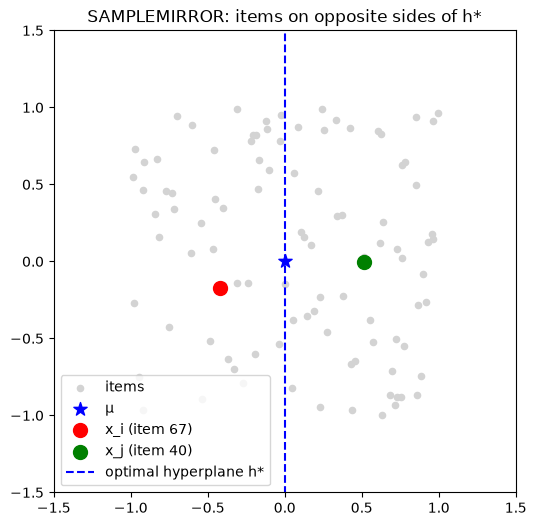

In [16]:
# Set up a simple test: 100 items in 2D, belief centered at origin with wide covariance
rng_test = np.random.default_rng(seed=0)
X_test = make_dataset(n=100, d=2, rng=rng_test)

mu_test = np.zeros(2)
Sigma_test = np.array([[1.0, 0.0], [0.0, 0.1]])  # much more variance along x-axis

used = set()
i, j = sample_mirror(mu_test, Sigma_test, X_test, used, rng_test)
print(f"query items: i={i}, j={j}")
print(f"  x_i = {X_test[i]}")
print(f"  x_j = {X_test[j]}")

# with high x-variance, hyperplane should be roughly perpendicular to x-axis,
# so the two query items should be on opposite sides in x
print(f"  x_i[0] and x_j[0] have opposite signs? {X_test[i][0] * X_test[j][0] < 0}")

# plot to visualize
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_test[:, 0], X_test[:, 1], c='lightgray', s=20, label='items')
ax.scatter(*mu_test, c='blue', s=100, marker='*', label='µ')
ax.scatter(*X_test[i], c='red', s=100, label=f'x_i (item {i})')
ax.scatter(*X_test[j], c='green', s=100, label=f'x_j (item {j})')
# draw the hyperplane (in 2D it's a line)
eigvals, eigvecs = np.linalg.eigh(Sigma_test)
w = eigvecs[:, -1]
# the hyperplane through mu perpendicular to w: parametrize as mu + t * perp
perp = np.array([-w[1], w[0]])
ts = np.linspace(-2, 2, 100)
line = mu_test[None, :] + ts[:, None] * perp[None, :]
ax.plot(line[:, 0], line[:, 1], 'b--', label='optimal hyperplane h*')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.legend()
ax.set_title("SAMPLEMIRROR: items on opposite sides of h*")
plt.show()

In [17]:
def adf_update(mu, Sigma, x_i, x_j, y, sigma_eps):
    """Assumed Density Filtering update for GAUSSSEARCH (Section 4.2 of the 2020 paper).
    
    Args:
        mu: (d,) current belief mean
        Sigma: (d, d) current belief covariance
        x_i, x_j: (d,) query items
        y: 0 if oracle picked i, 1 if oracle picked j
        sigma_eps: probit noise
    
    Returns:
        new (mu, Sigma) after Bayesian update.
    """
    # bisecting hyperplane
    w, b = bisecting_hyperplane(x_i, x_j)
    
    # if oracle picked j (y=1), flip sign of (w, b) so the observed answer
    # corresponds to the "positive" side of the plane
    if y == 1:
        w = -w
        b = -b
    
    # compute intermediate quantities
    wSw = w @ Sigma @ w                           # scalar: w^T Σ w
    denom = np.sqrt(wSw + sigma_eps**2)
    mu_w = mu @ w                                  # scalar: µ^T w
    g = (mu_w + b) / denom
    
    # first and second derivatives of log Φ(g) w.r.t. m = µ^T w
    phi_g = norm.pdf(g)
    Phi_g = norm.cdf(g)
    # guard against Phi_g = 0 (extreme cases)
    Phi_g = max(Phi_g, 1e-12)
    
    alpha = phi_g / (Phi_g * denom)
    beta = -alpha * (g / denom + alpha)
    
    # tau and nu
    tau = -beta / (1 + beta * wSw)
    nu = (alpha - beta * (mu_w + b)) / (1 + beta * wSw)
    
    # update covariance via Woodbury-style rank-1 correction:
    #   Σ_new = (Σ^{-1} + τ w w^T)^{-1}
    # equivalent to: Σ_new = Σ - (τ / (1 + τ w^T Σ w)) Σ w w^T Σ
    Sigma_w = Sigma @ w
    Sigma_new = Sigma - (tau / (1 + tau * wSw)) * np.outer(Sigma_w, Sigma_w)
    Sigma_new = symmetrize(Sigma_new)
    
    # update mean:
    #   µ_new = Σ_new [Σ^{-1} µ + (ν - b·τ) w]
    # equivalent to: µ_new = µ + Σ_new @ ((ν - b·τ - τ·(µ^T w)) w)
    #                     = µ + (ν - b·τ - τ·mu_w) · Σ_new @ w
    coeff = nu - b * tau - tau * mu_w
    mu_new = mu + coeff * (Sigma_new @ w)
    
    return mu_new, Sigma_new

In [30]:
# Set up a simple test: 1D belief centered at 0 with variance 1
# Query pair where x_i = 0.5, x_j = -0.5 (bisecting plane at 0)
# Oracle picks i (y=0), meaning target is likely > 0

mu_test = np.array([0.0])
Sigma_test = np.array([[1.0]])
x_i = np.array([0.5])
x_j = np.array([-0.8])

mu_new, Sigma_new = adf_update(mu_test, Sigma_test, x_i, x_j, y=0, sigma_eps=0.2)
print(f"before: mu={mu_test[0]:.4f}, sigma^2={Sigma_test[0,0]:.4f}")
print(f"after y=0 (picked i, target likely > 0):")
print(f"        mu={mu_new[0]:.4f}, sigma^2={Sigma_new[0,0]:.4f}")
print(f"expected: mu > 0 (mean shifted toward i), sigma^2 < 1 (uncertainty decreased)")

# now try y=1 (picked j, target likely < 0)
mu_new2, Sigma_new2 = adf_update(mu_test, Sigma_test, x_i, x_j, y=1, sigma_eps=0.2)
print(f"\nafter y=1 (picked j, target likely < 0):")
print(f"        mu={mu_new2[0]:.4f}, sigma^2={Sigma_new2[0,0]:.4f}")
print(f"expected: mu < 0 (mean shifted toward j), sigma^2 < 1 (uncertainty decreased)")

before: mu=0.0000, sigma^2=1.0000
after y=0 (picked i, target likely > 0):
        mu=0.6929, sigma^2=0.4199
expected: mu > 0 (mean shifted toward i), sigma^2 < 1 (uncertainty decreased)

after y=1 (picked j, target likely < 0):
        mu=-0.8765, sigma^2=0.3582
expected: mu < 0 (mean shifted toward j), sigma^2 < 1 (uncertainty decreased)


In [11]:
def gauss_search(X, target_idx, sigma_eps, max_queries=200, rng=None, stop_on="in_query"):
    """GAUSSSEARCH from Algorithm 2 of the 2020 paper.
    
    Args:
        stop_on: "in_query" (paper Section 6.3) — stop when target appears in query pair.
                 "argmax"   (paper Section 6.1) — stop when target has highest posterior.
    """
    if rng is None:
        rng = np.random.default_rng()
    n, d = X.shape
    x_t = X[target_idx]
    
    mu = np.zeros(d)
    Sigma = np.eye(d)
    
    used = set()
    history = {"Sigma_trace": [], "argmax": [], "dist_to_target": []}
    
    for step in range(max_queries):
        # compute argmax BEFORE this query (for argmax stopping)
        Sigma_inv = np.linalg.inv(Sigma + 1e-8 * np.eye(d))
        diffs = X - mu
        mahal2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
        argmax = int(np.argmin(mahal2))
        
        history["Sigma_trace"].append(float(np.trace(Sigma)))
        history["argmax"].append(argmax)
        history["dist_to_target"].append(float(np.linalg.norm(mu - x_t)))
        
        if stop_on == "argmax" and argmax == target_idx:
            return {"found": True, "n_queries": step, "history": history}
        
        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        
        y = query_oracle(X[i], X[j], x_t, sigma_eps, rng)
        
        if stop_on == "in_query" and target_idx in (i, j):
            return {"found": True, "n_queries": step + 1, "history": history}
        
        mu, Sigma = adf_update(mu, Sigma, X[i], X[j], y, sigma_eps)
    
    return {"found": False, "n_queries": max_queries, "history": history}

In [19]:
def run_scaling_experiment(n_values, d=5, sigma_eps=SIGMA_EPS, n_trials=200, seed=0, stop_on="argmax"):
    results = {}
    for n in n_values:
        rng_ds = np.random.default_rng(seed=seed)
        X = make_dataset(n=n, d=d, rng=rng_ds)
        rng_target = np.random.default_rng(seed=seed + 1)
        rng_search = np.random.default_rng(seed=seed + 2)
        query_counts = []
        for trial in tqdm(range(n_trials), desc=f"n={n}"):
            target_idx = int(rng_target.integers(0, n))
            res = gauss_search(X, target_idx, sigma_eps=sigma_eps,
                               max_queries=200, rng=rng_search, stop_on=stop_on)
            query_counts.append(res["n_queries"])
        results[n] = query_counts
        print(f"n={n:6d}: mean={np.mean(query_counts):.2f}, median={np.median(query_counts):.1f}, max={max(query_counts)}")
    return results

n_values = [50, 100, 500, 1000, 5000]
scaling_results = run_scaling_experiment(n_values, d=5, n_trials=200, stop_on="argmax")

n=50:   0%|          | 0/200 [00:00<?, ?it/s]

n=    50: mean=8.14, median=6.0, max=200


n=100:   0%|          | 0/200 [00:00<?, ?it/s]

n=   100: mean=10.65, median=8.0, max=108


n=500:   0%|          | 0/200 [00:00<?, ?it/s]

n=   500: mean=15.65, median=14.0, max=78


n=1000:   0%|          | 0/200 [00:00<?, ?it/s]

n=  1000: mean=20.59, median=18.0, max=97


n=5000:   0%|          | 0/200 [00:00<?, ?it/s]

n=  5000: mean=31.23, median=23.0, max=200


In [20]:
for n in n_values:
    counts = scaling_results[n]
    hits_max = sum(1 for c in counts if c >= 200)
    print(f"n={n:6d}: {hits_max}/{len(counts)} searches hit the 200-query ceiling")

n=    50: 1/200 searches hit the 200-query ceiling
n=   100: 0/200 searches hit the 200-query ceiling
n=   500: 0/200 searches hit the 200-query ceiling
n=  1000: 0/200 searches hit the 200-query ceiling
n=  5000: 1/200 searches hit the 200-query ceiling


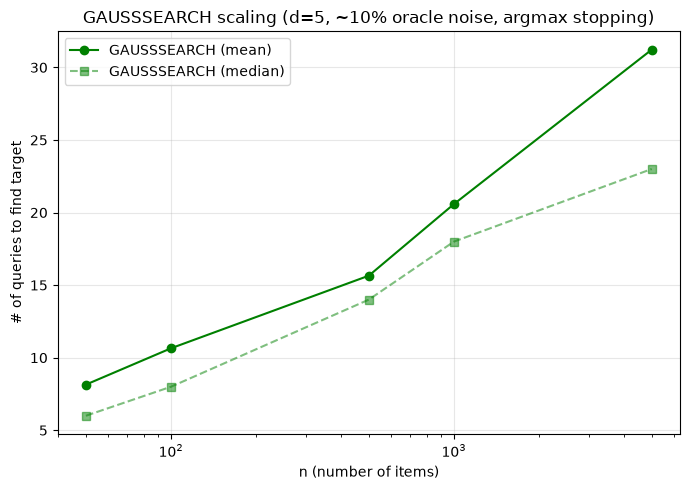

In [21]:
means = [np.mean(scaling_results[n]) for n in n_values]
medians = [np.median(scaling_results[n]) for n in n_values]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_values, means, marker='o', label='GAUSSSEARCH (mean)', color='green')
ax.plot(n_values, medians, marker='s', linestyle='--', label='GAUSSSEARCH (median)', color='green', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('n (number of items)')
ax.set_ylabel('# of queries to find target')
ax.set_title('GAUSSSEARCH scaling (d=5, ~10% oracle noise, argmax stopping)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
print(f"{'n':>6} | {'mean':>6} {'med':>4} {'p75':>4} {'p90':>4} {'p95':>4} {'p99':>4} {'max':>4} | {'>=2x_med':>8}")
print("-" * 70)
for n in n_values:
    counts = np.array(scaling_results[n])
    med = np.median(counts)
    n_above_2x = int((counts >= 2 * med).sum())
    print(f"{n:>6} | {np.mean(counts):>6.2f} {med:>4.0f} "
          f"{np.percentile(counts, 75):>4.0f} {np.percentile(counts, 90):>4.0f} "
          f"{np.percentile(counts, 95):>4.0f} {np.percentile(counts, 99):>4.0f} "
          f"{counts.max():>4.0f} | {n_above_2x:>4}/{len(counts)}")

     n |   mean  med  p75  p90  p95  p99  max | >=2x_med
----------------------------------------------------------------------
    50 |   8.14    6    9   13   17   27  200 |   28/200
   100 |  10.65    8   13   18   24   44  108 |   37/200
   500 |  15.65   14   21   28   34   40   78 |   24/200
  1000 |  20.59   18   25   36   47   70   97 |   22/200
  5000 |  31.23   23   34   56   76  177  200 |   31/200


In [23]:
def rand_search(X, target_idx, sigma_eps, max_queries=500, rng=None, stop_on="argmax"):
    """Random query baseline (RAND from Section 6.1).
    
    Identical to gauss_search except queries are chosen uniformly at random
    from unused items, not via SAMPLEMIRROR. The Gaussian belief still gets
    ADF-updated so the argmax stopping criterion is comparable.
    """
    if rng is None:
        rng = np.random.default_rng()
    n, d = X.shape
    x_t = X[target_idx]
    
    mu = np.zeros(d)
    Sigma = np.eye(d)
    
    used = set()
    history = {"Sigma_trace": [], "argmax": [], "dist_to_target": []}
    
    for step in range(max_queries):
        Sigma_inv = np.linalg.inv(symmetrize(Sigma) + 1e-8 * np.eye(d))
        diffs = X - mu
        mahal2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
        argmax = int(np.argmin(mahal2))
        
        history["Sigma_trace"].append(float(np.trace(Sigma)))
        history["argmax"].append(argmax)
        history["dist_to_target"].append(float(np.linalg.norm(mu - x_t)))
        
        if stop_on == "argmax" and argmax == target_idx:
            return {"found": True, "n_queries": step, "history": history}
        
        # random query pair from unused items
        available = [k for k in range(n) if k not in used]
        if len(available) < 2:
            break
        i, j = rng.choice(available, size=2, replace=False)
        i, j = int(i), int(j)
        used |= {i, j}
        
        y = query_oracle(X[i], X[j], x_t, sigma_eps, rng)
        
        if stop_on == "in_query" and target_idx in (i, j):
            return {"found": True, "n_queries": step + 1, "history": history}
        
        mu, Sigma = adf_update(mu, Sigma, X[i], X[j], y, sigma_eps)
    
    return {"found": False, "n_queries": max_queries, "history": history}

In [24]:
def run_scaling_experiment_generic(search_fn, n_values, d=5, sigma_eps=SIGMA_EPS,
                                    n_trials=200, seed=0, stop_on="argmax", max_queries=500,
                                    label=""):
    """Same as before but takes a search function as arg."""
    results = {}
    for n in n_values:
        rng_ds = np.random.default_rng(seed=seed)
        X = make_dataset(n=n, d=d, rng=rng_ds)
        rng_target = np.random.default_rng(seed=seed + 1)
        rng_search = np.random.default_rng(seed=seed + 2)
        query_counts = []
        for trial in tqdm(range(n_trials), desc=f"[{label}] n={n}"):
            target_idx = int(rng_target.integers(0, n))
            res = search_fn(X, target_idx, sigma_eps=sigma_eps,
                            max_queries=max_queries, rng=rng_search, stop_on=stop_on)
            query_counts.append(res["n_queries"])
        results[n] = query_counts
        print(f"n={n:6d}: mean={np.mean(query_counts):.2f}, median={np.median(query_counts):.1f}, max={max(query_counts)}")
    return results

# use smaller n for RAND — it scales linearly, so n=5000 with max_queries=500 might not converge
n_values_rand = [50, 100, 500, 1000]
rand_results = run_scaling_experiment_generic(
    rand_search, n_values_rand, d=5, n_trials=200,
    stop_on="argmax", max_queries=500, label="RAND"
)

[RAND] n=50:   0%|          | 0/200 [00:00<?, ?it/s]

n=    50: mean=37.96, median=7.0, max=500


[RAND] n=100:   0%|          | 0/200 [00:00<?, ?it/s]

n=   100: mean=26.84, median=10.0, max=500


[RAND] n=500:   0%|          | 0/200 [00:00<?, ?it/s]

n=   500: mean=25.45, median=20.0, max=127


[RAND] n=1000:   0%|          | 0/200 [00:00<?, ?it/s]

n=  1000: mean=31.82, median=25.0, max=141


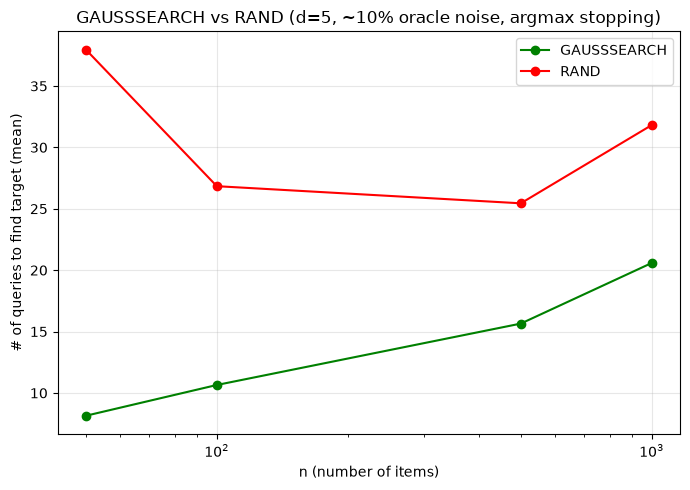

In [25]:
means_gs = [np.mean(scaling_results[n]) for n in n_values if n <= 1000]
means_rand = [np.mean(rand_results[n]) for n in n_values_rand]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([n for n in n_values if n <= 1000], means_gs, marker='o', label='GAUSSSEARCH', color='green')
ax.plot(n_values_rand, means_rand, marker='o', label='RAND', color='red')
ax.set_xscale('log')
ax.set_xlabel('n (number of items)')
ax.set_ylabel('# of queries to find target (mean)')
ax.set_title('GAUSSSEARCH vs RAND (d=5, ~10% oracle noise, argmax stopping)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
print(f"{'n':>6} | {'mean':>6} {'med':>4} {'p75':>4} {'p90':>4} {'p95':>4} {'p99':>4} {'max':>4} | {'hit_max':>8}")
print("-" * 70)
for n in n_values_rand:
    counts = np.array(rand_results[n])
    hit_max = int((counts >= 500).sum())
    print(f"{n:>6} | {np.mean(counts):>6.2f} {np.median(counts):>4.0f} "
          f"{np.percentile(counts, 75):>4.0f} {np.percentile(counts, 90):>4.0f} "
          f"{np.percentile(counts, 95):>4.0f} {np.percentile(counts, 99):>4.0f} "
          f"{counts.max():>4.0f} | {hit_max:>4}/{len(counts)}")

     n |   mean  med  p75  p90  p95  p99  max |  hit_max
----------------------------------------------------------------------
    50 |  37.96    7   13   22  500  500  500 |   12/200
   100 |  26.84   10   18   26   37  500  500 |    6/200
   500 |  25.45   20   32   51   64  114  127 |    0/200
  1000 |  31.82   25   41   63   72  114  141 |    0/200


In [27]:
n_values_iq = [50, 100, 500, 1000]
gauss_iq = run_scaling_experiment_generic(
    gauss_search, n_values_iq, d=5, n_trials=200,
    stop_on="in_query", max_queries=500, label="GAUSS-inQ"
)
rand_iq = run_scaling_experiment_generic(
    rand_search, n_values_iq, d=5, n_trials=200,
    stop_on="in_query", max_queries=500, label="RAND-inQ"
)

[GAUSS-inQ] n=50:   0%|          | 0/200 [00:00<?, ?it/s]

n=    50: mean=5.74, median=6.0, max=13


[GAUSS-inQ] n=100:   0%|          | 0/200 [00:00<?, ?it/s]

n=   100: mean=7.57, median=7.0, max=19


[GAUSS-inQ] n=500:   0%|          | 0/200 [00:00<?, ?it/s]

...

n=   100: mean=25.83, median=26.0, max=50


[RAND-inQ] n=500:   0%|          | 0/200 [00:00<?, ?it/s]

n=   500: mean=128.20, median=134.0, max=250


[RAND-inQ] n=1000:   0%|          | 0/200 [00:00<?, ?it/s]

n=  1000: mean=245.19, median=267.0, max=497


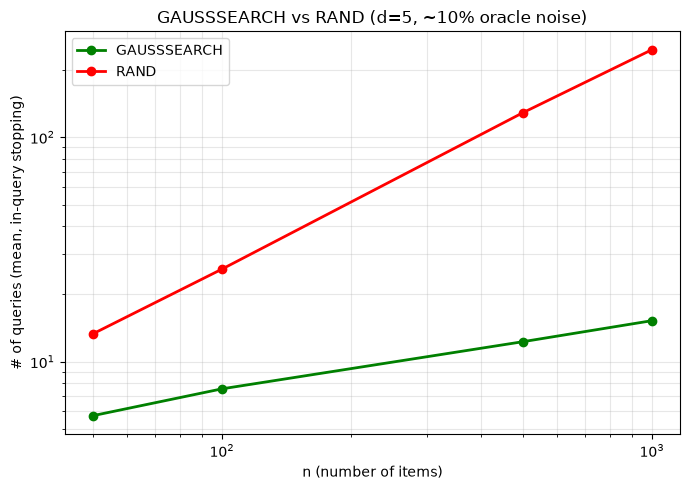

In [28]:
n_values_iq = [50, 100, 500, 1000]
means_gauss_iq = [np.mean(gauss_iq[n]) for n in n_values_iq]
means_rand_iq = [np.mean(rand_iq[n]) for n in n_values_iq]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_values_iq, means_gauss_iq, marker='o', label='GAUSSSEARCH', color='green', linewidth=2)
ax.plot(n_values_iq, means_rand_iq, marker='o', label='RAND', color='red', linewidth=2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('n (number of items)')
ax.set_ylabel('# of queries (mean, in-query stopping)')
ax.set_title('GAUSSSEARCH vs RAND (d=5, ~10% oracle noise)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
X_test_big = make_dataset(n=10000, d=2, rng=np.random.default_rng(seed=0))
mu_test = np.zeros(2)
Sigma_test = np.array([[1.0, 0.0], [0.0, 0.1]])
i, j = sample_mirror(mu_test, Sigma_test, X_test_big, set(), np.random.default_rng(seed=0))
print(f"x_i = {X_test_big[i]}")
print(f"x_j = {X_test_big[j]}")

x_i = [ 0.12241875 -0.04631336]
x_j = [-0.12123785 -0.03738102]
